In [108]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Input, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [109]:
RANDOM_SEED = 42

# Setting random seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

WINDOW_SIZE_EXPECTED = 30

In [110]:
X_TRAIN_PATH = (
    "../CMAPSSData/Processed/"
    "X_train_sequences(removed_the_sensor).npy"
)

Y_TRAIN_PATH = (
    "../CMAPSSData/Processed/"
    "y_train_sequences(removed_the_sensor).npy"
)

X_VAL_PATH = (
    "../CMAPSSData/Processed/"
    "X_val_sequences(removed_the_sensor).npy"
)

Y_VAL_PATH = (
    "../CMAPSSData/Processed/"
    "y_val_sequences(removed_the_sensor).npy"
)

In [111]:
BEST_MODEL_PATH = (
    "../Models/All_Sensor/"
    "LSTM_FD001_all_sensors_best.keras"
)

FINAL_MODEL_PATH = (
    "../Models/All_Sensor/"
    "LSTM_FD001_all_sensors_final.keras"
)

HISTORY_PATH = (
    "../Models/All_Sensor/"
    "LSTM_FD001_all_sensors_history.npz"
)

In [112]:
X_train = np.load(X_TRAIN_PATH)
y_train = np.load(Y_TRAIN_PATH)

X_val = np.load(X_VAL_PATH)
y_val = np.load(Y_VAL_PATH)


print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nValidation data:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


Training data:
X_train shape: (13818, 30, 18)
y_train shape: (13818,)

Validation data:
X_val shape: (3913, 30, 18)
y_val shape: (3913,)


In [113]:
print("\nX_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

print("\nX_train minimum:", X_train.min())
print("X_train maximum:", X_train.max())

print("\ny_train minimum:", y_train.min())
print("y_train maximum:", y_train.max())


X_train dtype: float32
y_train dtype: float32

X_train minimum: 0.0
X_train maximum: 1.0

y_train minimum: 0.0
y_train maximum: 332.0


In [114]:
print("DATA VALIDATION")

if X_train.ndim != 3:
    raise ValueError(
        f"X_train must be 3-dimensional. "
        f"Found shape: {X_train.shape}"
    )

if X_val.ndim != 3:
    raise ValueError(
        f"X_val must be 3-dimensional. "
        f"Found shape: {X_val.shape}"
    )

window_size = X_train.shape[1]

if window_size != WINDOW_SIZE_EXPECTED:
    print(
        f"\nWARNING: Expected window size "
        f"{WINDOW_SIZE_EXPECTED}, "
        f"but found {window_size}."
    )

number_of_features = X_train.shape[2]

if X_val.shape[2] != number_of_features:
    raise ValueError(
        "Training and validation datasets have "
        "different numbers of features."
    )

if len(X_train) != len(y_train):
    raise ValueError(
        "X_train and y_train have different "
        "numbers of samples."
    )

if len(X_val) != len(y_val):
    raise ValueError(
        "X_val and y_val have different "
        "numbers of samples."
    )

print("\nNaN values:")

print("X_train:", np.isnan(X_train).sum())
print("y_train:", np.isnan(y_train).sum())
print("X_val:", np.isnan(X_val).sum())
print("y_val:", np.isnan(y_val).sum())


print("\nInfinite values:")

print("X_train:", np.isinf(X_train).sum())
print("y_train:", np.isinf(y_train).sum())
print("X_val:", np.isinf(X_val).sum())
print("y_val:", np.isinf(y_val).sum())


if (
    np.isnan(X_train).any()
    or np.isnan(y_train).any()
    or np.isnan(X_val).any()
    or np.isnan(y_val).any()
):
    raise ValueError("NaN values detected in the dataset.")

if (
    np.isinf(X_train).any()
    or np.isinf(y_train).any()
    or np.isinf(X_val).any()
    or np.isinf(y_val).any()
):
    raise ValueError(
        "Infinite values detected in the dataset."
    )

DATA VALIDATION

NaN values:
X_train: 0
y_train: 0
X_val: 0
y_val: 0

Infinite values:
X_train: 0
y_train: 0
X_val: 0
y_val: 0


In [115]:
print("INPUT INFORMATION")

print("\nWindow size:", window_size)
print("Number of features:", number_of_features)
print(
    "Input shape:",
    X_train.shape[1:]
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


print("\nTraining RUL range:")
print("Minimum:", y_train.min())
print("Maximum:", y_train.max())

print("\nValidation RUL range:")
print("Minimum:", y_val.min())
print("Maximum:", y_val.max())

INPUT INFORMATION

Window size: 30
Number of features: 18
Input shape: (30, 18)

Training samples: 13818
Validation samples: 3913

Training RUL range:
Minimum: 0.0
Maximum: 332.0

Validation RUL range:
Minimum: 0.0
Maximum: 311.0


In [116]:
print("Builidng LSTM Model")

INPUT_SHAPE = X_train.shape[1:]

model = Sequential([
    Input(shape=INPUT_SHAPE),
    LSTM(
            128, 
            return_sequences=True, 
            recurrent_dropout=0.0
        ),
        BatchNormalization(),
        Dropout(0.2),
    LSTM(
        64,
        return_sequences=True, 
    ),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dropout(0.1),
    
    Dense(1)
])

Builidng LSTM Model


In [117]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [118]:
print("LSTM Model Architecture")
model.summary()

LSTM Model Architecture


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,401 (540.63 KB)

 Trainable params: 138,017 (539.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [119]:
print("SETTING TRAINING CALLBACKS")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    mode='min',
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

SETTING TRAINING CALLBACKS


In [120]:
print("STARTING LSTM TRAINING")

history = model.fit(
    X_train, y_train, 
    validation_data=(
        X_val, 
        y_val
    ),
    epochs=100,
    batch_size=64,
    callbacks=[
        early_stopping, 
        reduce_lr, 
        model_checkpoint
    ],
    verbose=1
)

STARTING LSTM TRAINING
Epoch 1/100
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 7155.6606 - mae: 64.6172
Epoch 1: val_loss improved from None to 6960.77246, saving model to ../Models/All_Sensor/LSTM_FD001_all_sensors_best.keras

Epoch 1: finished saving model to ../Models/All_Sensor/LSTM_FD001_all_sensors_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 7145.9229 - mae: 64.5561 - val_loss: 6960.7725 - val_mae: 63.5465 - learning_rate: 0.0010
Epoch 2/100
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2444.7788 - mae: 33.3782
Epoch 2: val_loss did not improve from 6960.77246
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 2442.6101 - mae: 33.3570 - val_loss: 14809.3916 - val_mae: 95.8166 - learning_rate: 0.0010
Epoch 3/100
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1314.3408 - mae: 24.3088
Epoch 3: val_loss improved from 6960.77246 to 6244.18359, saving model to ../Models/All_Sensor/LSTM_FD001_all_sensors_best.keras

Epoch 3: finished saving model to ../Mode

In [121]:
model.save(FINAL_MODEL_PATH)

print("MODEL TRAINING COMPLETED")

print("\nFinal model saved at:")
print(FINAL_MODEL_PATH)

print("\nBest model saved at:")
print(BEST_MODEL_PATH)

MODEL TRAINING COMPLETED

Final model saved at:
../Models/All_Sensor/LSTM_FD001_all_sensors_final.keras

Best model saved at:
../Models/All_Sensor/LSTM_FD001_all_sensors_best.keras


In [122]:
np.savez(
    HISTORY_PATH,
    
    loss=np.array(
        history.history["loss"]
    ),

    val_loss=np.array(
        history.history["val_loss"]
    ),

    mae=np.array(
        history.history["mae"]
    ),

    val_mae=np.array(
        history.history["val_mae"]
    )
)

In [123]:
print("TRAINING INFORMATION")

print("Total epochs requested", 100)
print("Actual epochs completed:", len(history.history['loss']))
print("Best validation loss:", min(history.history["val_loss"] ))
print("Best validation MAE:", min(history.history["val_mae"]))

TRAINING INFORMATION
Total epochs requested 100
Actual epochs completed: 20
Best validation loss: 1691.556396484375
Best validation MAE: 26.917430877685547


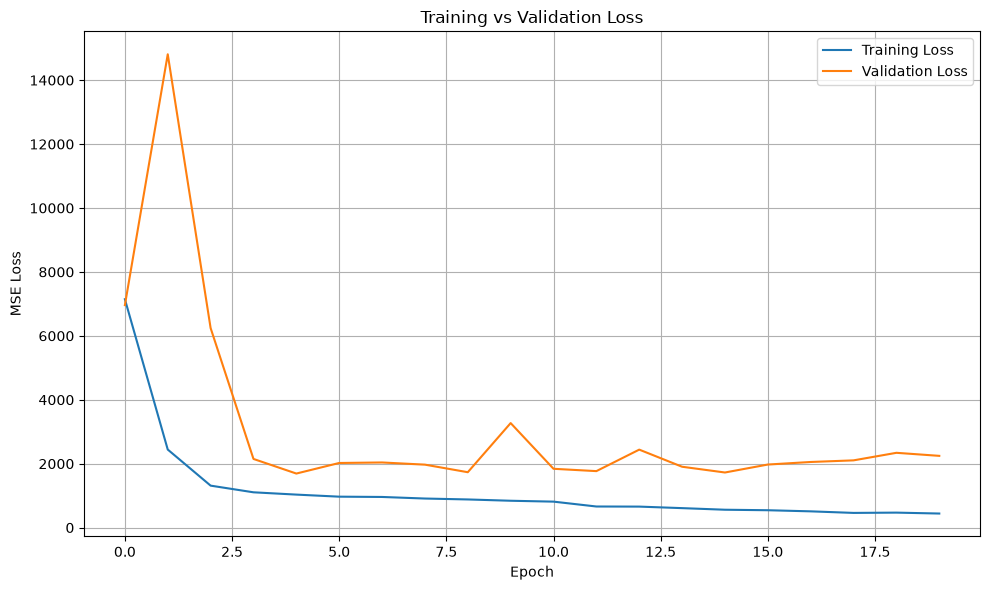

In [124]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

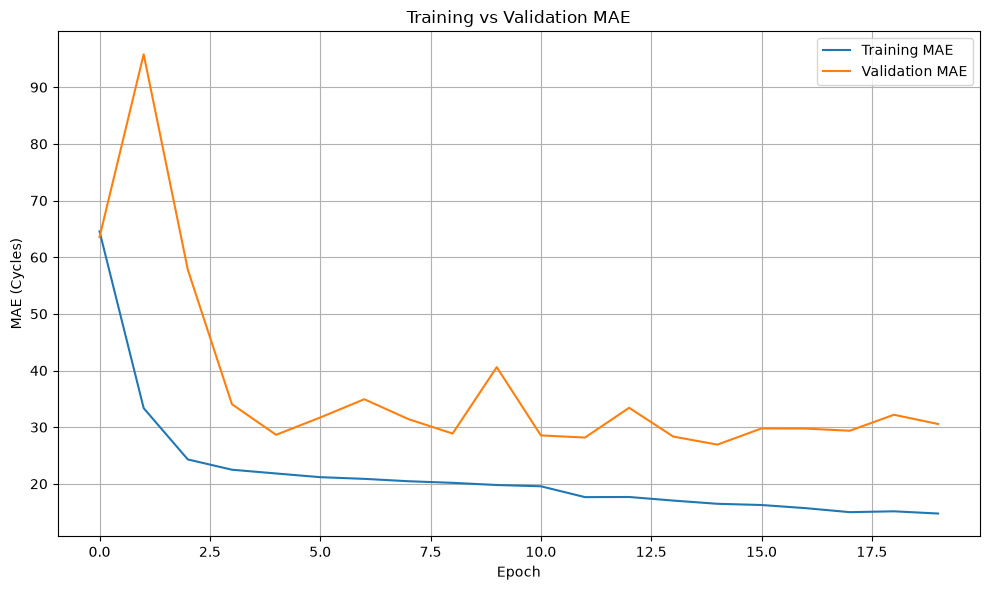

In [125]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["mae"],label="Training MAE")

plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE (Cycles)")
plt.title("Training vs Validation MAE")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

In [126]:
print("VALIDATION PREDICTION")

y_pred = model.predict(
    X_val,
    verbose=1
)

y_pred = y_pred.reshape(-1)

mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

VALIDATION PREDICTION
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


In [127]:
print("VALIDATION PERFORMANCE")

print(f"\nMAE : {mae:.4f} cycles")

print(f"RMSE  : {rmse:.4f} cycles")

print(f"R²    : {r2:.4f}")

VALIDATION PERFORMANCE

MAE : 28.6529 cycles
RMSE  : 41.1285 cycles
R²    : 0.6610


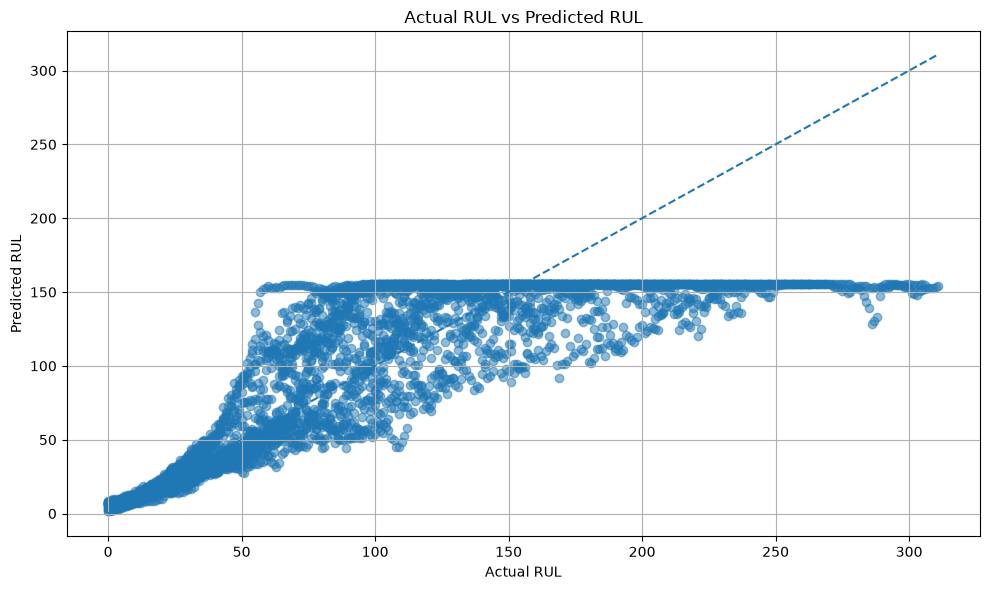

In [128]:
plt.figure(figsize=(10, 6))

plt.scatter(y_val, y_pred, alpha=0.5)

# Perfect prediction line

minimum = min(y_val.min(), y_pred.min())

maximum = max(y_val.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Actual RUL vs Predicted RUL")

plt.grid(True)

plt.tight_layout()

plt.show()

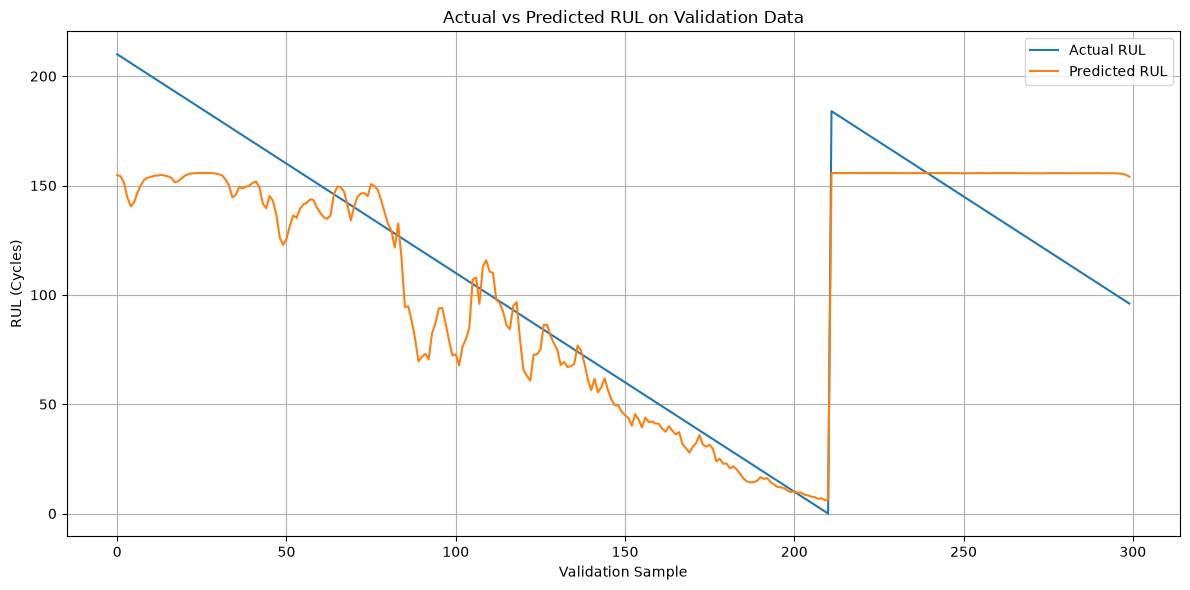

In [129]:
number_to_plot = min(300, len(y_val))

plt.figure(figsize=(12, 6))

plt.plot(y_val[:number_to_plot], label="Actual RUL")

plt.plot(y_pred[:number_to_plot], label="Predicted RUL")

plt.xlabel("Validation Sample")
plt.ylabel("RUL (Cycles)")

plt.title("Actual vs Predicted RUL on Validation Data")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [131]:
print("FINAL SUMMARY")

print(f"Validation MAE  : {mae:.4f} cycles")

print(f"Validation RMSE : {rmse:.4f} cycles")

print(f"Validation R²   : {r2:.4f}")

print("\nTraining completed successfully.")

FINAL SUMMARY
Validation MAE  : 28.6529 cycles
Validation RMSE : 41.1285 cycles
Validation R²   : 0.6610

Training completed successfully.
